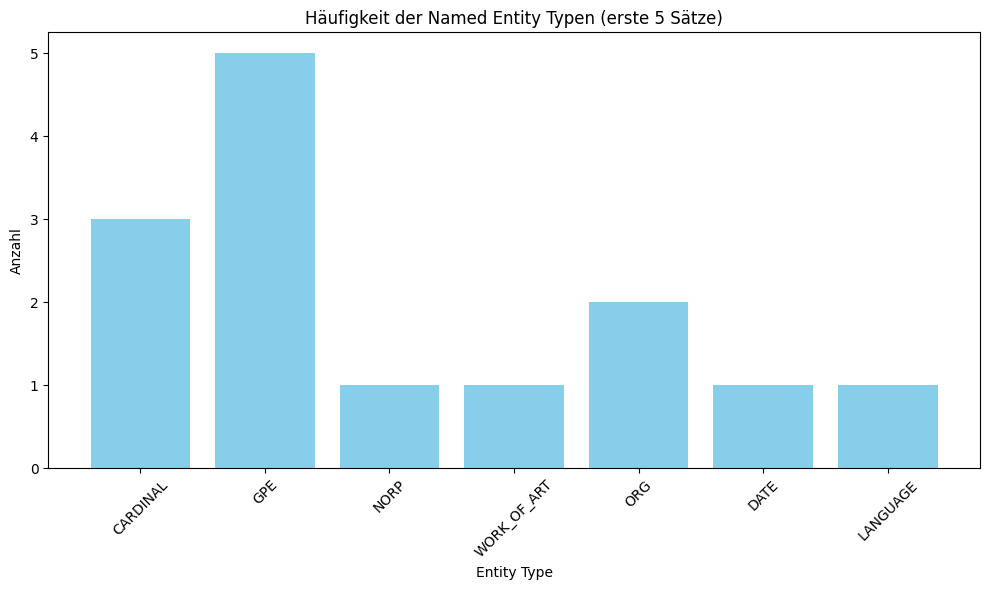

In [10]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# CSV laden (erste 100 Zeilen)
df = pd.read_csv("ner.csv", nrows=100)

# spaCy NLP-Pipeline laden
nlp = spacy.load("en_core_web_sm")

# Annahme: die Textspalte heißt "Sentence"
if "Sentence" in df.columns:
    texts = df["Sentence"].dropna().tolist()
else:
    texts = df.iloc[:, 0].dropna().tolist()  # Fallback auf erste Spalte

# Nur die ersten 5 Sätze verarbeiten
first_five = texts[:5]

# spaCy-Dokumente erstellen
docs = list(nlp.pipe(first_five))

# Alle Entitäten extrahieren
all_ents = []
for doc in docs:
    for ent in doc.ents:
        all_ents.append(ent.label_)

# Häufigkeit der Entitäten berechnen
ent_freq = Counter(all_ents)

# Visualisierung mit Matplotlib
plt.figure(figsize=(10, 6))
plt.bar(ent_freq.keys(), ent_freq.values(), color='skyblue')
plt.title('Häufigkeit der Named Entity Typen (erste 5 Sätze)')
plt.xlabel('Entity Type')
plt.ylabel('Anzahl')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

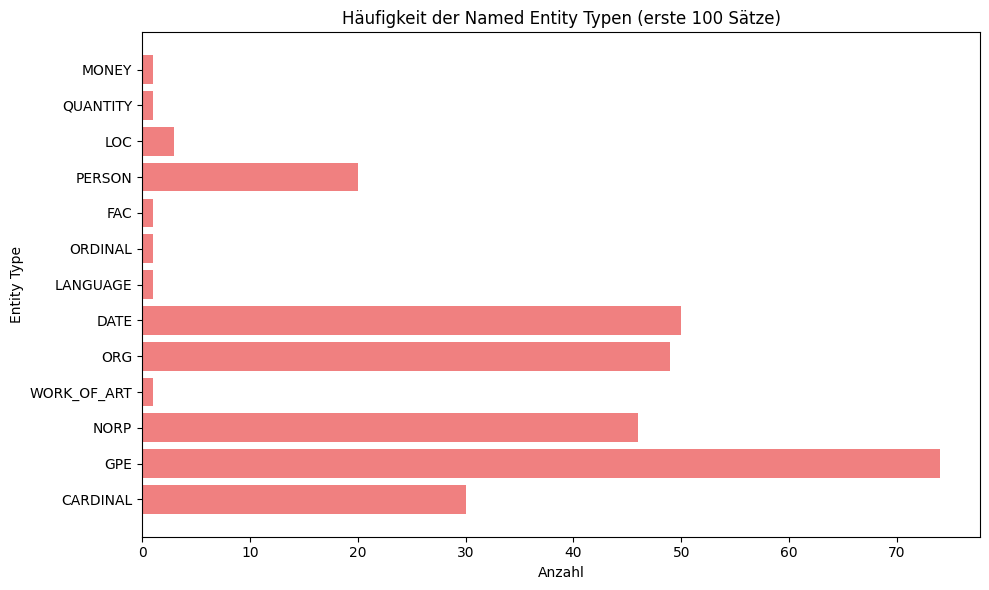

In [11]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# CSV laden (erste 100 Zeilen)
df = pd.read_csv("ner.csv", nrows=100)

# spaCy NLP-Pipeline laden
nlp = spacy.load("en_core_web_sm")

# Annahme: die Textspalte heißt "Sentence"
if "Sentence" in df.columns:
    texts = df["Sentence"].dropna().tolist()
else:
    texts = df.iloc[:, 0].dropna().tolist()  # Fallback auf erste Spalte

# Nur die ersten 100 Sätze verarbeiten
first_100 = texts[:100]

# spaCy-Dokumente erstellen
docs = list(nlp.pipe(first_100))

# Alle Entitäten extrahieren
all_ents = []
for doc in docs:
    for ent in doc.ents:
        all_ents.append(ent.label_)

# Häufigkeit der Entitäten berechnen
ent_freq = Counter(all_ents)

# Visualisierung der Häufigkeitsverteilung mit einem horizontalen Balkendiagramm
plt.figure(figsize=(10, 6))
plt.barh(list(ent_freq.keys()), list(ent_freq.values()), color='lightcoral')
plt.title('Häufigkeit der Named Entity Typen (erste 100 Sätze)')
plt.xlabel('Anzahl')
plt.ylabel('Entity Type')
plt.tight_layout()
plt.show()

Skript um die BIO Tags auf spaCy Token zu mappen

In [24]:
import spacy
import pandas as pd
import ast
from difflib import SequenceMatcher

# Lade Original-CSV
df = pd.read_csv("ner_100.csv", sep=";", quotechar='"', escapechar='\\')
nlp = spacy.load("en_core_web_sm")

def align_tokens(original_tokens, spacy_tokens):
    """Versucht die spaCy-Tokens mit den ursprünglichen Token aus der Datei zu matchen."""
    sm = SequenceMatcher(None, original_tokens, spacy_tokens)
    mapping = {}
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal':
            for i, j in zip(range(i1, i2), range(j1, j2)):
                mapping[j] = i  # map spaCy index j -> original index i
    return mapping

new_rows = []
skipped = 0

for idx, row in df.iterrows():
    sentence = row["Sentence"]
    try:
        original_tags = ast.literal_eval(row["Tag"])
    except Exception as e:
        print(f"⚠️ Fehler beim Parsen von Tags in Zeile {idx}: {e}")
        skipped += 1
        continue

    original_tokens = sentence.split()
    doc = nlp(sentence)
    spacy_tokens = [token.text for token in doc]

    if len(original_tags) != len(original_tokens):
        print(f"⚠️ Zeile {idx} übersprungen: original token/tag mismatch ({len(original_tokens)} vs {len(original_tags)})")
        skipped += 1
        continue

    # Versuche Token-Mapping
    mapping = align_tokens(original_tokens, spacy_tokens)

    # Neue Tags mit 'O' vorausfüllen
    spacy_tags = ['O'] * len(spacy_tokens)

    for spacy_idx, original_idx in mapping.items():
        spacy_tags[spacy_idx] = original_tags[original_idx]

    new_rows.append({
        "Sentence": sentence,
        "Tag": str(spacy_tags)
    })

# Neue DataFrame und CSV speichern
df_cleaned = pd.DataFrame(new_rows)
df_cleaned.to_csv("ner_100_spacy.csv", sep=';', index=False, quotechar='"')

print(f"✅ Fertig! {len(df_cleaned)} Zeilen konvertiert. {skipped} Zeilen übersprungen.")

⚠️ Zeile 76 übersprungen: original token/tag mismatch (37 vs 38)
✅ Fertig! 99 Zeilen konvertiert. 1 Zeilen übersprungen.


F1-Score for GPE: 0.7230
F1-Score for PERSON: 0.6966
F1-Score for ORG: 0.6860
F1-Score (weighted): 0.7056


/opt/anaconda3/envs/nlp_env/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['O'] will be ignored
  warnings.warn(


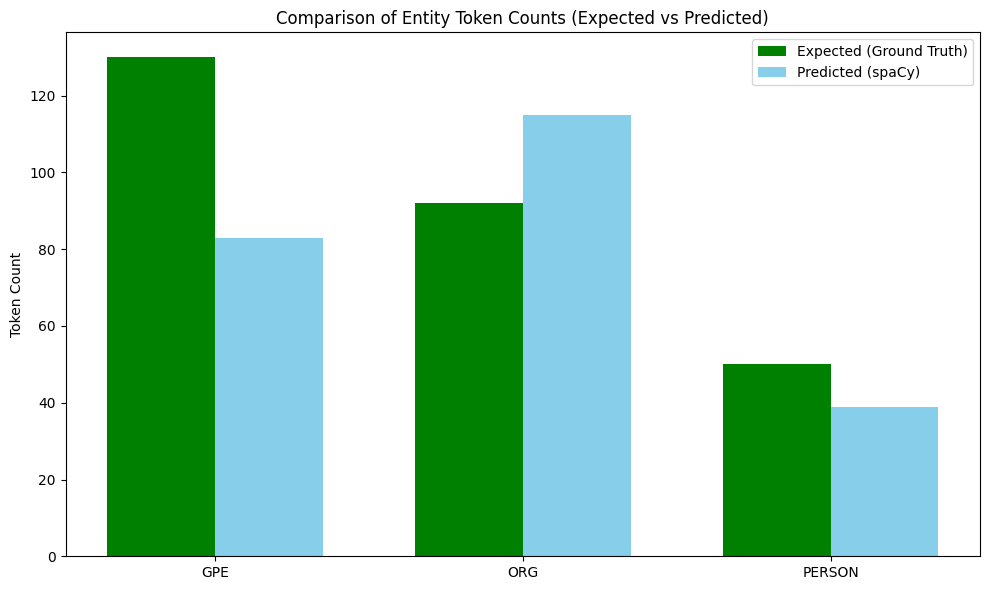

In [26]:
import spacy
import pandas as pd
from sklearn.metrics import f1_score
from collections import Counter
import ast
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

# Load the CSV file with proper handling
df = pd.read_csv("ner_100_spacy.csv", sep=';', quotechar='"', escapechar='\\')

# Load spaCy NLP pipeline
nlp = spacy.load("en_core_web_sm")

# Extract sentences and tags
texts = df["Sentence"].tolist()
tags = df["Tag"].apply(ast.literal_eval).tolist()

# Function to convert BIO tags to entity labels
def bio_to_entity_labels(tokens, bio_tags):
    entity_labels = []
    current_label = None
    
    for token, tag in zip(tokens, bio_tags):
        if tag.startswith('B-'):
            current_label = tag[2:].upper()
            entity_labels.append(current_label)
        elif tag.startswith('I-'):
            if current_label is not None:
                entity_labels.append(current_label)
            else:
                entity_labels.append('O')
        else:
            entity_labels.append('O')
            current_label = None
    
    return entity_labels

# Process ground truth tags
true_labels = []
for i, (sentence, bio_tags) in enumerate(zip(texts, tags)):
    doc = nlp(sentence)
    tokens = [token.text for token in doc]
    
    if len(tokens) != len(bio_tags):
        print(f"⚠️  Token/Tag mismatch in row {i}:")
        print(f"Sentence: {sentence}")
        print(f"Tokens ({len(tokens)}): {tokens}")
        print(f"Tags   ({len(bio_tags)}): {bio_tags}")
        continue  # skip this sentence


    entity_labels = bio_to_entity_labels(tokens, bio_tags)
    # Filter only GPE, PERSON, ORG (convert variations)
    filtered_labels = []
    for label in entity_labels:
        if label in ['GPE', 'PERSON', 'ORG', 'GEO', 'PER']:
            if label in ['GEO']:
                label = 'GPE'
            elif label in ['PER']:
                label = 'PERSON'
            filtered_labels.append(label)
        else:
            filtered_labels.append('O')
    true_labels.append(filtered_labels)

# Process texts with spaCy and get predictions
pred_labels = []
for doc in nlp.pipe(texts):
    doc_labels = ['O'] * len(doc)
    for ent in doc.ents:
        if ent.label_ in ['GPE', 'PERSON', 'ORG']:
            for i in range(ent.start, ent.end):
                if i < len(doc_labels):
                    doc_labels[i] = ent.label_
    pred_labels.append(doc_labels)

true_token_labels = [label for sublist in true_labels for label in sublist]
pred_token_labels = [label for sublist in pred_labels for label in sublist]

# Ensure same length
assert len(true_token_labels) == len(pred_token_labels), "Lengths do not match!"

# Use MultiLabelBinarizer to handle the labels
mlb = MultiLabelBinarizer(classes=['GPE', 'PERSON', 'ORG'])

# Convert to binary indicator format
y_true = mlb.fit_transform([[label] for label in true_token_labels])
y_pred = mlb.transform([[label] for label in pred_token_labels])

# Calculate F1 score if we have predictions
if true_token_labels and pred_token_labels:
    # Use MultiLabelBinarizer to handle the labels
    mlb = MultiLabelBinarizer(classes=['GPE', 'PERSON', 'ORG'])
    
    # Convert to binary indicator format
    y_true = mlb.fit_transform([[label] for label in true_token_labels])
    y_pred = mlb.transform([[label] for label in pred_token_labels])
    
    # Calculate F1 score for each class
    f1_gpe = f1_score(y_true[:, 0], y_pred[:, 0], average='binary')
    f1_person = f1_score(y_true[:, 1], y_pred[:, 1], average='binary')
    f1_org = f1_score(y_true[:, 2], y_pred[:, 2], average='binary')
    
    print(f"F1-Score for GPE: {f1_gpe:.4f}")
    print(f"F1-Score for PERSON: {f1_person:.4f}")
    print(f"F1-Score for ORG: {f1_org:.4f}")
    
    # Calculate weighted average
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"F1-Score (weighted): {weighted_f1:.4f}")
else:
    print("Warning: Empty predictions or ground truth. Cannot calculate F1 score.")

# Zähle Ground Truth und Predicted Labels (ohne "O")
true_counts = Counter(label for label in true_token_labels if label != "O")
pred_counts = Counter(label for label in pred_token_labels if label != "O")

# Gemeinsame Labels
all_labels = sorted(set(true_counts.keys()).union(pred_counts.keys()))

# Daten für Plot
true_vals = [true_counts.get(label, 0) for label in all_labels]
pred_vals = [pred_counts.get(label, 0) for label in all_labels]

# Plot
x = range(len(all_labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], true_vals, width=width, label='Expected (Ground Truth)', color='green')
plt.bar([i + width/2 for i in x], pred_vals, width=width, label='Predicted (spaCy)', color='skyblue')

plt.xticks(ticks=x, labels=all_labels)
plt.ylabel("Token Count")
plt.title("Comparison of Entity Token Counts (Expected vs Predicted)")
plt.legend()
plt.tight_layout()
plt.show()